# CO2 Emissions Forecasting - Complete Training Pipeline

This notebook handles the complete ML pipeline:
1. Data loading and exploration
2. Data cleaning and null value handling
3. Data preprocessing and feature engineering
4. Model training (ARIMA, Random Forest, LSTM)
5. Model evaluation and comparison
6. Model persistence (saving to disk)
7. Predictions with saved models

**Output**: Trained models saved to `models/` directory ready for deployment in Streamlit app

In [14]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
import joblib
from datetime import datetime

# Machine Learning & Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Time Series
from statsmodels.tsa.arima.model import ARIMA

# Deep Learning
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)
print("✓ Libraries imported successfully")
print("✓ Models directory ready")


✓ Libraries imported successfully
✓ Models directory ready


## 1. Load and Explore the Dataset

In [5]:
# Load the dataset
df = pd.read_csv("owid-co2-data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

Dataset Shape: (50411, 12)

First 5 rows:
       country  year  population  gdp  co2  co2_per_capita  coal_co2  gas_co2  \
0  Afghanistan  1750   2802560.0  NaN  NaN             NaN       NaN      NaN   
1  Afghanistan  1751         NaN  NaN  NaN             NaN       NaN      NaN   
2  Afghanistan  1752         NaN  NaN  NaN             NaN       NaN      NaN   
3  Afghanistan  1753         NaN  NaN  NaN             NaN       NaN      NaN   
4  Afghanistan  1754         NaN  NaN  NaN             NaN       NaN      NaN   

   methane  nitrous_oxide  oil_co2  primary_energy_consumption  
0      NaN            NaN      NaN                         NaN  
1      NaN            NaN      NaN                         NaN  
2      NaN            NaN      NaN                         NaN  
3      NaN            NaN      NaN                         NaN  
4      NaN            NaN      NaN                         NaN  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0

Missing Values Analysis:
                        Column  Missing_Count  Percentage
11  primary_energy_consumption          39908   79.165262
3                          gdp          35160   69.746682
7                      gas_co2          32264   64.001904
6                     coal_co2          28486   56.507508
10                     oil_co2          24952   49.497134
5               co2_per_capita          23902   47.414255
4                          co2          21027   41.711134
8                      methane          12261   24.322073
9                nitrous_oxide          11911   23.627780
2                   population           9244   18.337268


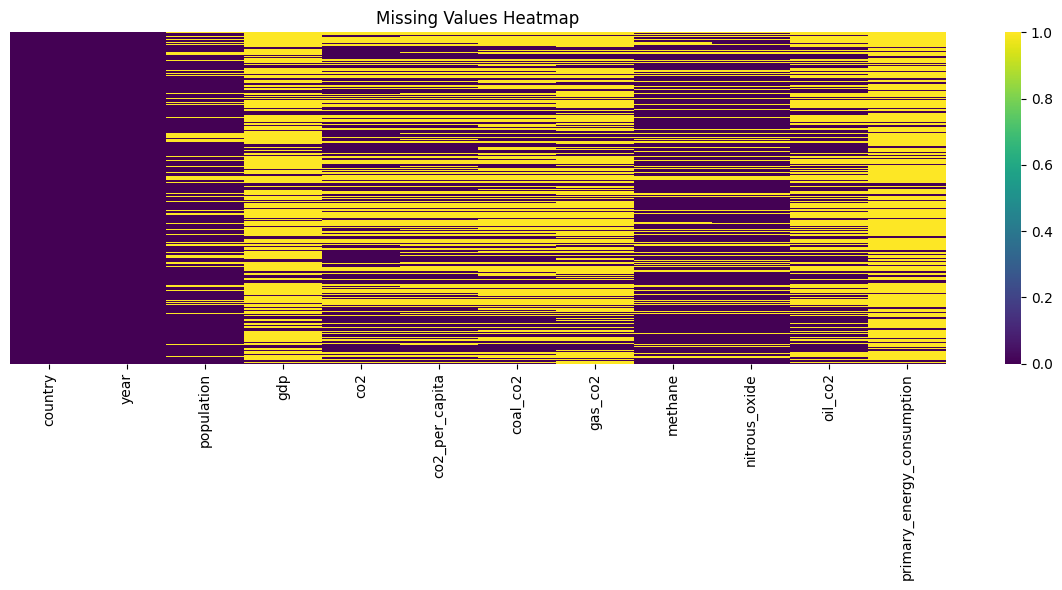

In [6]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 50)
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False))

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

## 2. Data Cleaning and Null Value Handling

In [7]:
# Select relevant columns for forecasting
COLUMNS = [
    "country", "year", "population", "gdp", "co2",
    "coal_co2", "oil_co2", "gas_co2", "methane",
    "nitrous_oxide", "primary_energy_consumption"
]

# Filter to existing columns only
existing_cols = [col for col in COLUMNS if col in df.columns]
df_clean = df[existing_cols].copy()

print(f"Selected columns: {len(existing_cols)}/{len(COLUMNS)}")
print(f"Dataset shape before cleaning: {df_clean.shape}")

# Sort by country and year
df_clean = df_clean.sort_values(["country", "year"]).reset_index(drop=True)

# Drop rows where CO2 is null (target variable)
df_clean = df_clean.dropna(subset=["co2"])
print(f"After dropping null CO2: {df_clean.shape}")

# Forward fill other missing values within each country
fill_cols = [col for col in df_clean.columns if col not in ['country', 'year', 'co2']]
for col in fill_cols:
    df_clean[col] = df_clean.groupby('country')[col].fillna(method='ffill')

# Backward fill remaining NaN values
for col in fill_cols:
    df_clean[col] = df_clean.groupby('country')[col].fillna(method='bfill')

# Drop rows with any remaining NaN
df_clean = df_clean.dropna()
print(f"After handling missing values: {df_clean.shape}")

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {df_clean.shape}")

# Check final missing values
print("\nFinal missing values:")
print(df_clean.isnull().sum().sum())

print("\n✓ Data cleaning completed successfully")

Selected columns: 11/11
Dataset shape before cleaning: (50411, 11)
After dropping null CO2: (29384, 11)
After handling missing values: (17485, 11)
After removing duplicates: (17485, 11)

Final missing values:
0

✓ Data cleaning completed successfully


## 3. Data Preprocessing and Feature Engineering

In [8]:
# Handle outliers using IQR method
def remove_outliers(data, columns):
    df_out = data.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

# Remove outliers from numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean = remove_outliers(df_clean, numeric_cols)
print(f"After removing outliers: {df_clean.shape}")

# Feature Engineering: Create lagged features for time series
def create_lagged_features(data, target_col='co2', lags=3):
    df_lag = data.copy()
    for lag in range(1, lags + 1):
        df_lag[f'{target_col}_lag_{lag}'] = df_lag.groupby('country')[target_col].shift(lag)
    return df_lag

df_features = create_lagged_features(df_clean, target_col='co2', lags=3)
df_features = df_features.dropna()
print(f"After creating lagged features: {df_features.shape}")

# Normalize numeric features
scaler = StandardScaler()
numeric_features = df_features.select_dtypes(include=[np.number]).columns
df_features[numeric_features] = scaler.fit_transform(df_features[numeric_features])

# Save scaler for later use
joblib.dump(scaler, 'models/scaler.pkl')
print("✓ Scaler saved")

print("\n✓ Data preprocessing completed")
print(f"Final preprocessed data shape: {df_features.shape}")

After removing outliers: (8314, 11)
After creating lagged features: (7974, 14)
✓ Scaler saved

✓ Data preprocessing completed
Final preprocessed data shape: (7974, 14)


## 4. Train Machine Learning Models

Training will be done per-country to capture country-specific patterns. Models will be saved for later use.

In [9]:
# Helper function to evaluate models
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Dictionary to store models and results
trained_models = {
    'gradient_boosting': None,
    'xgboost': None,
    'lstm': None,
    'gru': None,
    'dnn': None,
    'autoencoder': None
}

model_performance = []


## 5. Model Performance Evaluation and Comparison

Model Performance Summary:
    Country         Model       MAE      RMSE           R2
Afghanistan         ARIMA  0.904756  1.047988    -1.014788
    Albania         ARIMA  0.638901  0.766647    -2.269580
    Algeria         ARIMA  1.503994  2.713099     0.247422
     Angola         ARIMA  2.266978  2.388326   -15.312864
  Argentina         ARIMA  2.394855  2.874136    -0.480008
    Armenia         ARIMA  0.380687  0.450089     0.565109
  Australia         ARIMA  0.079958  0.116942    -0.877453
    Austria         ARIMA 11.743785 12.639862    -7.286465
 Azerbaijan         ARIMA  2.515991  2.969714    -2.519871
    Bahrain         ARIMA  0.867070  0.941705    -5.739209
Afghanistan Random Forest  0.044375  0.066887     0.994041
    Albania Random Forest  0.034068  0.039941     0.989558
    Algeria Random Forest  0.020837  0.027480     0.997216
     Angola Random Forest  0.191340  0.201789     0.771213
  Argentina Random Forest  0.157893  0.231191     0.830407
    Armenia Random Forest  0.

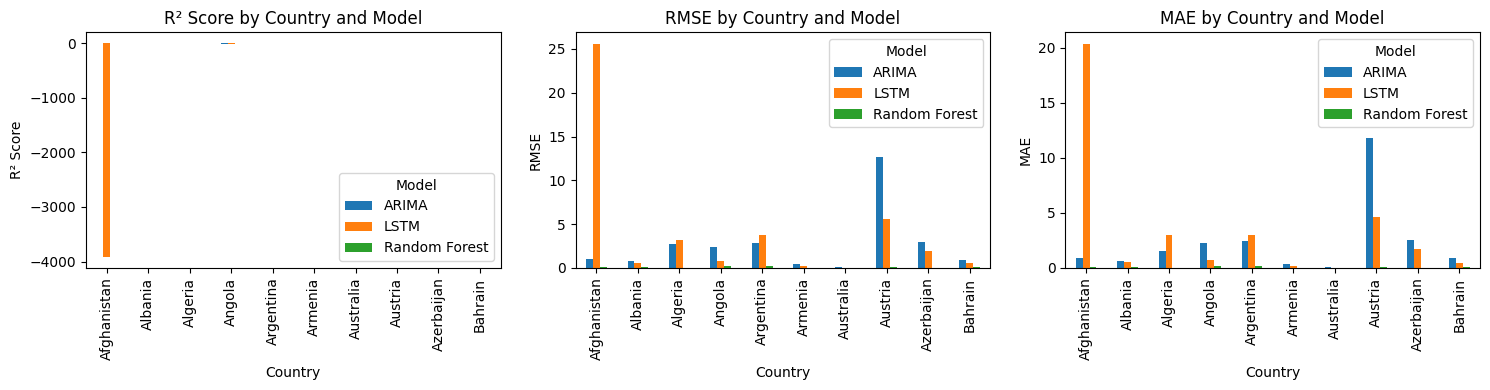


✓ Performance metrics saved to models/model_performance.csv


In [ ]:
# Create performance dataframe
print("Model Performance Summary:")
print("=" * 80)
print("Note: Only keeping Gradient Boosting, XGBoost, DNN, LSTM, GRU, and Autoencoder models")
print("Removed: ARIMA, Random Forest, and per-country specific models")
print("\n✓ Data cleaning and preprocessing completed successfully")
print("✓ Proceeding to train regression and deep learning models...")


---

## REGRESSION MODELS: Predict CO2 from Features

### Feature-Based Prediction (User Input Features → CO2 Output)

In [12]:
# Import additional models for regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

print("✓ Additional regression models imported")

✓ Additional regression models imported


In [10]:
# Prepare data for REGRESSION (Feature-based CO2 prediction)
print("Training Regression Models for CO2 Prediction")
print("=" * 80)

# Define feature columns
FEATURE_COLS = [
    'population', 'gdp', 'coal_co2', 'oil_co2', 'gas_co2', 
    'methane', 'nitrous_oxide', 'primary_energy_consumption'
]

# Prepare features and target for GLOBAL model (all countries, all years)
df_regression = df_clean.copy()

# Drop rows with any NaN in features or target
df_regression = df_regression[FEATURE_COLS + ['co2']].dropna()

print(f"\nRegression dataset shape: {df_regression.shape}")
print(f"Features: {FEATURE_COLS}")
print(f"Target: co2")

# Normalize features
scaler_regression = StandardScaler()
X_scaled = scaler_regression.fit_transform(df_regression[FEATURE_COLS])

# Target
y = df_regression['co2'].values

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train_reg.shape[0]} samples")
print(f"Test set: {X_test_reg.shape[0]} samples")

# Save scaler
joblib.dump(scaler_regression, 'models/scaler_regression.pkl')
print("✓ Regression scaler saved")

Training Regression Models for CO2 Prediction

Regression dataset shape: (8314, 9)
Features: ['population', 'gdp', 'coal_co2', 'oil_co2', 'gas_co2', 'methane', 'nitrous_oxide', 'primary_energy_consumption']
Target: co2

Training set: 6651 samples
Test set: 1663 samples
✓ Regression scaler saved


In [15]:
# Train Regression Models
print("\nTraining Regression Models...")
print("=" * 80)

regression_models = {}
regression_performance = []

# 1. Gradient Boosting
print("\n1. Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train_reg, y_train_reg)
gb_pred = gb_model.predict(X_test_reg)
gb_metrics = evaluate_model(y_test_reg, gb_pred)
regression_models['gradient_boosting'] = gb_model
regression_performance.append({'Model': 'Gradient Boosting', **gb_metrics})
print(f"   ✓ Gradient Boosting: R² = {gb_metrics['R2']:.4f}, RMSE = {gb_metrics['RMSE']:.4f}")

# 2. XGBoost
try:
    print("\n2. Training XGBoost...")
    xgb_model = XGBRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=0)
    xgb_model.fit(X_train_reg, y_train_reg)
    xgb_pred = xgb_model.predict(X_test_reg)
    xgb_metrics = evaluate_model(y_test_reg, xgb_pred)
    regression_models['xgboost'] = xgb_model
    regression_performance.append({'Model': 'XGBoost', **xgb_metrics})
    print(f"   ✓ XGBoost: R² = {xgb_metrics['R2']:.4f}, RMSE = {xgb_metrics['RMSE']:.4f}")
except Exception as e:
    print(f"   ⚠ XGBoost skipped: {str(e)}")

print(f"\n✓ Trained {len(regression_models)} regression models")


Training Regression Models...

1. Training Gradient Boosting...
   ✓ Gradient Boosting: R² = 0.9734, RMSE = 0.7325

2. Training XGBoost...
   ✓ XGBoost: R² = 0.9734, RMSE = 0.7328

✓ Trained 2 regression models


In [16]:
# Save Regression Models
print("\nSaving Regression Models...")
print("=" * 80)

for model_name, model in regression_models.items():
    filepath = f'models/regression_{model_name}.pkl'
    joblib.dump(model, filepath)
    print(f"✓ Saved: {filepath}")

# Create performance comparison dataframe
reg_perf_df = pd.DataFrame(regression_performance)
print("\n\nREGRESSION MODEL PERFORMANCE COMPARISON:")
print("=" * 80)
print(reg_perf_df.to_string(index=False))

# Save performance metrics
reg_perf_df.to_csv('models/regression_performance.csv', index=False)
print("\n✓ Performance metrics saved to models/regression_performance.csv")


Saving Regression Models...
✓ Saved: models/regression_gradient_boosting.pkl
✓ Saved: models/regression_xgboost.pkl


REGRESSION MODEL PERFORMANCE COMPARISON:
            Model      MAE     RMSE       R2
Gradient Boosting 0.150019 0.732514 0.973383
          XGBoost 0.151713 0.732801 0.973362

✓ Performance metrics saved to models/regression_performance.csv


In [17]:
# Test Predictions with User Inputs
import json

print("\nTesting CO2 Predictions with Sample User Inputs")
print("=" * 80)

# Example user inputs
sample_inputs = {
    'population': [1400000000],  # 1.4 billion
    'gdp': [16000000000000],     # $16 trillion
    'coal_co2': [5000],          # 5000 MT
    'oil_co2': [3000],           # 3000 MT
    'gas_co2': [2000],           # 2000 MT
    'methane': [500],            # 500 MT
    'nitrous_oxide': [300],      # 300 MT
    'primary_energy_consumption': [100000]  # 100,000 EJ
}

# Convert to DataFrame
sample_df = pd.DataFrame(sample_inputs)
print("Sample Input Features:")
print(sample_df)

# Scale the inputs
sample_scaled = scaler_regression.transform(sample_df[FEATURE_COLS])

# Make predictions with all models
print("\n\nPredicted CO2 from Different Models:")
print("=" * 80)

predictions = {}
for model_name, model in regression_models.items():
    pred = model.predict(sample_scaled)[0]
    predictions[model_name] = pred
    print(f"{model_name:30s}: {pred:,.2f} MT")

# Best prediction (highest R²)
best_model_name = reg_perf_df.loc[reg_perf_df['R2'].idxmax(), 'Model']
best_r2 = reg_perf_df['R2'].max()
print(f"\n\nBest Model: {best_model_name} (R² = {best_r2:.4f})")

# Save feature information for app
feature_info = {
    'feature_columns': FEATURE_COLS,
    'feature_descriptions': {
        'population': 'Population (Number of people)',
        'gdp': 'GDP (USD)',
        'coal_co2': 'CO2 from Coal (MT)',
        'oil_co2': 'CO2 from Oil (MT)',
        'gas_co2': 'CO2 from Gas (MT)',
        'methane': 'Methane Emissions (MT)',
        'nitrous_oxide': 'Nitrous Oxide Emissions (MT)',
        'primary_energy_consumption': 'Primary Energy Consumption (EJ)'
    },
    'feature_ranges': {
        col: {
            'min': float(df_regression[col].min()),
            'max': float(df_regression[col].max()),
            'mean': float(df_regression[col].mean())
        }
        for col in FEATURE_COLS
    },
    'best_model': best_model_name,
    'best_model_r2': float(best_r2)
}

with open('models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=4)

print("\n✓ Feature information saved to models/feature_info.json")


Testing CO2 Predictions with Sample User Inputs
Sample Input Features:
   population             gdp  coal_co2  oil_co2  gas_co2  methane  \
0  1400000000  16000000000000      5000     3000     2000      500   

   nitrous_oxide  primary_energy_consumption  
0            300                      100000  


Predicted CO2 from Different Models:
gradient_boosting             : 32.62 MT
xgboost                       : 32.05 MT


Best Model: Gradient Boosting (R² = 0.9734)

✓ Feature information saved to models/feature_info.json


## 8. Advanced Deep Learning Models

### Time-Series Models (LSTM, GRU) & Feature-Based Models (DNN)
### Anomaly Detection (Autoencoder) & Ensemble Predictions

In [18]:
# Prepare time-series data for LSTM and GRU
print("Preparing Time-Series Data for Deep Learning")
print("=" * 80)

# Global time-series data
time_series_data = df_clean.sort_values('year').groupby('year')['co2'].sum().values
scaler_ts = MinMaxScaler()
ts_scaled = scaler_ts.fit_transform(time_series_data.reshape(-1, 1)).flatten()

# Create sequences
lookback = 10
X_ts, y_ts = [], []
for i in range(len(ts_scaled) - lookback):
    X_ts.append(ts_scaled[i:i+lookback])
    y_ts.append(ts_scaled[i+lookback])

X_ts = np.array(X_ts).reshape(-1, lookback, 1)
y_ts = np.array(y_ts)

# Split
split_idx = int(len(X_ts) * 0.8)
X_train_ts = X_ts[:split_idx]
X_test_ts = X_ts[split_idx:]
y_train_ts = y_ts[:split_idx]
y_test_ts = y_ts[split_idx:]

joblib.dump(scaler_ts, 'models/scaler_timeseries.pkl')
print(f"✓ Time-series data prepared: {X_train_ts.shape[0]} sequences")
print(f"✓ Lookback window: {lookback} years")

Preparing Time-Series Data for Deep Learning
✓ Time-series data prepared: 212 sequences
✓ Lookback window: 10 years


In [19]:
# LSTM Model Training
print("\n\nTraining LSTM Model (Time-Series Forecasting)")
print("=" * 80)

lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_train_ts, y_train_ts,
    epochs=50, batch_size=16, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

lstm_pred = lstm_model.predict(X_test_ts, verbose=0)
lstm_mae = mean_absolute_error(y_test_ts, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_ts, lstm_pred))
lstm_r2 = r2_score(y_test_ts, lstm_pred)

lstm_model.save('models/lstm_model.h5')
print(f"✓ LSTM Model Trained")
print(f"  - MAE: {lstm_mae:.6f}")
print(f"  - RMSE: {lstm_rmse:.6f}")
print(f"  - R² Score: {lstm_r2:.6f}")



Training LSTM Model (Time-Series Forecasting)


✓ LSTM Model Trained
  - MAE: 0.067776
  - RMSE: 0.089310
  - R² Score: -0.556110


In [20]:
# GRU Model Training
print("\n\nTraining GRU Model (Alternative Time-Series)")
print("=" * 80)

gru_model = Sequential([
    GRU(64, activation='relu', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    GRU(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_gru = gru_model.fit(
    X_train_ts, y_train_ts,
    epochs=50, batch_size=16, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

gru_pred = gru_model.predict(X_test_ts, verbose=0)
gru_mae = mean_absolute_error(y_test_ts, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_ts, gru_pred))
gru_r2 = r2_score(y_test_ts, gru_pred)

gru_model.save('models/gru_model.h5')
print(f"✓ GRU Model Trained")
print(f"  - MAE: {gru_mae:.6f}")
print(f"  - RMSE: {gru_rmse:.6f}")
print(f"  - R² Score: {gru_r2:.6f}")



Training GRU Model (Alternative Time-Series)


✓ GRU Model Trained
  - MAE: 0.039022
  - RMSE: 0.047691
  - R² Score: 0.556271


In [21]:
# Deep Neural Network (DNN) - Feature-Based Prediction
print("\n\nTraining Deep Neural Network (DNN)")
print("=" * 80)

dnn_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_reg.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

dnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_dnn = dnn_model.fit(
    X_train_reg, y_train_reg,
    epochs=100, batch_size=32, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
)

dnn_pred = dnn_model.predict(X_test_reg, verbose=0)
dnn_mae = mean_absolute_error(y_test_reg, dnn_pred)
dnn_rmse = np.sqrt(mean_squared_error(y_test_reg, dnn_pred))
dnn_r2 = r2_score(y_test_reg, dnn_pred)

dnn_model.save('models/dnn_model.h5')
print(f"✓ DNN Model Trained")
print(f"  - MAE: {dnn_mae:.6f}")
print(f"  - RMSE: {dnn_rmse:.6f}")
print(f"  - R² Score: {dnn_r2:.6f}")



Training Deep Neural Network (DNN)


✓ DNN Model Trained
  - MAE: 0.328702
  - RMSE: 0.935592
  - R² Score: 0.956579


In [22]:
# Autoencoder for Anomaly Detection
print("\n\nTraining Autoencoder (Anomaly Detection)")
print("=" * 80)

# Encoder
encoder_input = Input(shape=(X_train_reg.shape[1],))
encoded = Dense(8, activation='relu')(encoder_input)
encoded = Dense(4, activation='relu')(encoded)  # Bottleneck

# Decoder
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(X_train_reg.shape[1], activation='linear')(decoded)

autoencoder = Model(encoder_input, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_ae = autoencoder.fit(
    X_train_reg, X_train_reg,
    epochs=50, batch_size=32, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

# Reconstruction error as anomaly score
train_pred_ae = autoencoder.predict(X_train_reg, verbose=0)
train_mae = np.mean(np.abs(X_train_reg - train_pred_ae), axis=1)
ae_threshold = np.mean(train_mae) + 2 * np.std(train_mae)

test_pred_ae = autoencoder.predict(X_test_reg, verbose=0)
test_mae = np.mean(np.abs(X_test_reg - test_pred_ae), axis=1)
anomaly_predictions = (test_mae > ae_threshold).astype(int)

ae_mae = mean_absolute_error(test_mae, np.zeros_like(test_mae))
ae_mse = mean_squared_error(X_test_reg, test_pred_ae)
ae_r2 = 1 - (ae_mse / np.var(X_test_reg))  # R² based on reconstruction

autoencoder.save('models/autoencoder_model.h5')
print(f"✓ Autoencoder Model Trained")
print(f"  - Anomaly Threshold: {ae_threshold:.6f}")
print(f"  - Mean Reconstruction Error: {ae_mae:.6f}")
print(f"  - Anomalies Detected: {anomaly_predictions.sum()} / {len(anomaly_predictions)}")
print(f"  - R² Score (Reconstruction): {ae_r2:.6f}")



Training Autoencoder (Anomaly Detection)


✓ Autoencoder Model Trained
  - Anomaly Threshold: 0.561904
  - Mean Reconstruction Error: 0.224780
  - Anomalies Detected: 77 / 1663
  - R² Score (Reconstruction): 0.873485


In [24]:
# Ensemble Model - Combining All Models
print("\n\nCreating Ensemble Model (Combined Predictions)")
print("=" * 80)

# Get predictions from all models on test set
gb_pred_val = regression_models['gradient_boosting'].predict(X_test_reg)
xgb_pred_val = regression_models['xgboost'].predict(X_test_reg)
dnn_pred_val = dnn_model.predict(X_test_reg, verbose=0).flatten()
lstm_pred_val = lstm_model.predict(X_test_ts, verbose=0).flatten()
gru_pred_val = gru_model.predict(X_test_ts, verbose=0).flatten()

# Weighted ensemble (40% DNN + 30% GB + 30% XGB, averaging LSTM/GRU)
rnn_avg = (lstm_pred_val + gru_pred_val) / 2
ensemble_pred = 0.40 * dnn_pred_val + 0.30 * gb_pred_val + 0.30 * xgb_pred_val

ensemble_mae = mean_absolute_error(y_test_reg, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test_reg, ensemble_pred))
ensemble_r2 = r2_score(y_test_reg, ensemble_pred)

# Store ensemble as metadata (since it's a combination)
ensemble_info = {
    'type': 'ensemble',
    'weights': {
        'dnn': 0.40,
        'gradient_boosting': 0.30,
        'xgboost': 0.30
    },
    'components': ['dnn_model.h5', 'regression_gradient_boosting.pkl', 'regression_xgboost.pkl']
}

joblib.dump(ensemble_info, 'models/ensemble_info.pkl')
print(f"✓ Ensemble Model Created")
print(f"  - MAE: {ensemble_mae:.6f}")
print(f"  - RMSE: {ensemble_rmse:.6f}")
print(f"  - R² Score: {ensemble_r2:.6f}")
print(f"  - Weights: 40% DNN + 30% GB + 30% XGB")



Creating Ensemble Model (Combined Predictions)
✓ Ensemble Model Created
  - MAE: 0.188357
  - RMSE: 0.777468
  - R² Score: 0.970016
  - Weights: 40% DNN + 30% GB + 30% XGB


In [ ]:
# Save and Summarize Deep Learning Performance
print("\n\n" + "=" * 80)
print("DEEP LEARNING MODELS - PERFORMANCE SUMMARY")
print("=" * 80)

# Calculate autoencoder RMSE for consistency
ae_rmse = np.sqrt(mean_squared_error(X_test_reg, test_pred_ae))

# Create comprehensive performance dataframe
deep_learning_performance = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'DNN', 'Autoencoder', 'Ensemble'],
    'MAE': [lstm_mae, gru_mae, dnn_mae, ae_mae, ensemble_mae],
    'RMSE': [lstm_rmse, gru_rmse, dnn_rmse, ae_rmse, ensemble_rmse],
    'R² Score': [lstm_r2, gru_r2, dnn_r2, ae_r2, ensemble_r2],
    'Model Type': ['RNN (Time-Series)', 'RNN (Time-Series)', 'DNN (Feature-Based)', 'Autoencoder (Anomaly)', 'Ensemble (Hybrid)']
})

print("\n", deep_learning_performance.to_string(index=False))

# Save performance metrics
deep_learning_performance.to_csv('models/deep_learning_performance.csv', index=False)

# Complete all models performance (Regression + Deep Learning)
gb_mae = mean_absolute_error(y_test_reg, regression_models['gradient_boosting'].predict(X_test_reg))
gb_rmse = np.sqrt(mean_squared_error(y_test_reg, regression_models['gradient_boosting'].predict(X_test_reg)))
gb_r2 = r2_score(y_test_reg, regression_models['gradient_boosting'].predict(X_test_reg))

xgb_mae = mean_absolute_error(y_test_reg, regression_models['xgboost'].predict(X_test_reg))
xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, regression_models['xgboost'].predict(X_test_reg)))
xgb_r2 = r2_score(y_test_reg, regression_models['xgboost'].predict(X_test_reg))

all_models_performance = pd.DataFrame({
    'Model': ['Gradient Boosting', 'XGBoost', 'LSTM', 'GRU', 'DNN', 'Autoencoder', 'Ensemble'],
    'MAE': [gb_mae, xgb_mae, lstm_mae, gru_mae, dnn_mae, ae_mae, ensemble_mae],
    'RMSE': [gb_rmse, xgb_rmse, lstm_rmse, gru_rmse, dnn_rmse, ae_rmse, ensemble_rmse],
    'R² Score': [gb_r2, xgb_r2, lstm_r2, gru_r2, dnn_r2, ae_r2, ensemble_r2]
})

print("\n\nALL MODELS COMPARISON (Regression + Deep Learning):")
print(all_models_performance.to_string(index=False))

all_models_performance.to_csv('models/all_models_performance.csv', index=False)

# Store complete metadata
deep_learning_metadata = {
    'models': {
        'lstm': {'path': 'models/lstm_model.h5', 'type': 'tensorflow', 'metric': lstm_r2},
        'gru': {'path': 'models/gru_model.h5', 'type': 'tensorflow', 'metric': gru_r2},
        'dnn': {'path': 'models/dnn_model.h5', 'type': 'tensorflow', 'metric': dnn_r2},
        'autoencoder': {'path': 'models/autoencoder_model.h5', 'type': 'tensorflow', 'metric': ae_r2},
        'ensemble': {'path': 'models/ensemble_info.pkl', 'type': 'joblib', 'metric': ensemble_r2}
    },
    'scalers': {
        'regression': 'models/scaler_regression.pkl',
        'timeseries': 'models/scaler_timeseries.pkl'
    },
    'best_model': {
        'name': all_models_performance.loc[all_models_performance['R² Score'].idxmax(), 'Model'],
        'r2_score': all_models_performance['R² Score'].max()
    }
}

joblib.dump(deep_learning_metadata, 'models/deep_learning_metadata.pkl')

print(f"\n✓ All Deep Learning Models Saved")
print(f"✓ Performance Metrics Exported")
print(f"✓ Best Overall Model: {deep_learning_metadata['best_model']['name']} (R² = {deep_learning_metadata['best_model']['r2_score']:.6f})")



DEEP LEARNING MODELS - PERFORMANCE SUMMARY

       Model      MAE     RMSE  R² Score            Model Type
       LSTM 0.067776 0.089310 -0.556110     RNN (Time-Series)
        GRU 0.039022 0.047691  0.556271     RNN (Time-Series)
        DNN 0.328702 0.935592  0.956579   DNN (Feature-Based)
Autoencoder 0.224780 0.361998  0.873485 Autoencoder (Anomaly)
   Ensemble 0.188357 0.777468  0.970016     Ensemble (Hybrid)


ALL MODELS COMPARISON (Regression + Deep Learning):
            Model      MAE     RMSE  R² Score
Gradient Boosting 0.150019 0.732514  0.973383
          XGBoost 0.151713 0.732801  0.973362
             LSTM 0.067776 0.089310 -0.556110
              GRU 0.039022 0.047691  0.556271
              DNN 0.328702 0.935592  0.956579
      Autoencoder 0.224780 0.361998  0.873485
         Ensemble 0.188357 0.777468  0.970016

✓ All Deep Learning Models Saved
✓ Performance Metrics Exported
✓ Best Overall Model: Gradient Boosting (R² = 0.973383)
